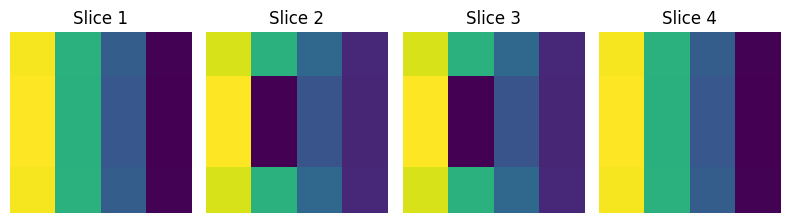

[[-5.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[1.0 ,-4.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[0.0 ,1.0 ,-4.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[0.0 ,0.0 ,1.0 ,-5.0 ,0.

C:\Users\Rafael\AppData\Local\Temp\ipykernel_25732\4099190374.py:17: RuntimeWarning: overflow encountered in cast
  residuals[row] = residual


In [1]:
%run darcy_solver.ipynb

In [2]:
import os
os.chdir("..")
print(os.getcwd())

D:\Python\PyFlowSolver


In [37]:
%run .\pyflowsolver\volumeManager.py
%run .\pyflowsolver\sparseArray.py
%run .\pyflowsolver\fastLaplacian.py
%run .\pyflowsolver\darcySolver.py

In [4]:
import porespy as ps

D:\Anaconda\envs\notebook\Lib\site-packages\pyamg\multilevel.py:10: UserWarning: Module pyflowsolver was already imported from None, but d:\python\pyflowsolver is being added to sys.path
  from pkg_resources import parse_version  # included with setuptools
D:\Anaconda\envs\notebook\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
vol = ps.generators.blobs(shape=(100, 100, 100), porosity=0.35)

In [6]:
import numpy as np
import scipy as sc

In [7]:
lab, n_lab = sc.ndimage.label(vol)

In [8]:
print(np.unique(lab[0,:,:]))
print(np.unique(lab[-1,:,:]))
print(np.unique(lab[:,0,:]))
print(np.unique(lab[:,-1,:]))
print(np.unique(lab[:,:,0]))
print(np.unique(lab[:,:,-1]))

[0 1 2 3 4 5]
[ 0  1 34 35]
[ 0  1  2  8 17 19 23 31]
[ 0  1  5  9 16 18 21 33 35]
[ 0  1  4  6 17]
[ 0  1  3 12 32]


In [29]:
con_vol = (lab==1)*100

In [30]:
con_vol = fast_laplacian_volume_generator(
    con_vol, 
    (1.2, 1.2, 1.2), 
    )

In [32]:
volume_manager = VolumeManager(con_vol)

In [33]:
A, b = volume_manager.get_sparse_system()

In [34]:
A

In [35]:
b

array([-0.72000003,  0.        ,  0.        , ...,  0.        ,
        0.        ,  0.        ])

In [ ]:
sparse_A, sparse_b = A, b
solver = DarcySolver()
solution = solver.solve(sparse_A, sparse_b)
raveled_solution = volume_manager.ravel_sparse_solution(solution)